# PhysiCar SIM

Simulation HTTP API — served under `/sim/api/`, same layout as the physicar-sim README. Sections are ordered by how often you will reach for them.

## [0] Setup

In [1]:
import requests

BASE_URL = "http://localhost/sim/api"

# This API exists only in SIM mode — a real kit has no /sim/api
try:
    requests.get(f"{BASE_URL}/status", timeout=3).raise_for_status()
except requests.RequestException:
    raise SystemExit("Simulator not found — this notebook needs the PhysiCar simulator (SIM mode).")

## [1] Status & Time

### 1.1. Status

`GET /status` — simulator runtime status.

In [2]:
requests.get(f"{BASE_URL}/status").json()

{'running': True,
 'websocket': True,
 'current': 'custom_71e69ee938032295503bfed557fde18c',
 'switching': False,
 'assets_version': 1787050679}

### 1.2. Clock

`GET /clock` — sim time / real time / RTF / paused.

In [3]:
requests.get(f"{BASE_URL}/clock").json()

{'sim_time': 276.37,
 'real_time': 284.870207236,
 'rtf': 0.9999188065929047,
 'paused': False}

## [2] Vehicle

### 2.1. Pose

`GET /pose` — vehicle pose (world absolute coordinates).

In [4]:
requests.get(f"{BASE_URL}/pose").json()

{'x': 1.400004,
 'y': 3.370147,
 'z': -0.0,
 'yaw': -1.570678,
 'q': [0.0, 0.0, -0.707065, 0.707148]}

### 2.2. Teleport

`POST /pose` — `{"x": 1.0, "y": 2.0, "yaw": 0.0}`; omitted fields keep their current value. The pose is normalized upright at ground level, so this also rights a flipped car. The response returns after the pose is confirmed applied.

In [5]:
pose = requests.get(f"{BASE_URL}/pose").json()
requests.post(f"{BASE_URL}/pose", json={"x": pose["x"] + 0.3}).json()

{'ok': True,
 'applied': True,
 'pose': {'x': 1.700004, 'y': 3.368602, 'z': 0.05, 'yaw': -1.570678}}

## [3] World & Objects

### 3.1. World

`GET /world` — one-call snapshot of the current world's immutable definition: identity (`world_id`/`rev`/display name), track geometry, object catalog, and whether it has an evaluation.

In [6]:
world = requests.get(f"{BASE_URL}/world").json()
print({k: world[k] for k in ("world", "world_id", "rev", "display", "evaluation")})
print("track keys :", list(world["track"].keys()))
print("objects    :", list(world["objects"].keys()))

{'world': 'custom_71e69ee938032295503bfed557fde18c', 'world_id': '71e69ee938032295503bfed557fde18c', 'rev': 'msxw4l0xae4bc354', 'display': 'AMET 2026', 'evaluation': True}
track keys : ['route', 'bounds']
objects    : ['cone2', 'light1', 'cone4', 'cone1', 'cone3', 'cone5', 'cone6', 'wall_0', 'wall_1', 'wall_2', 'wall_3']


### 3.2. Route

`GET /route` — track centerline waypoints, plus inner/outer boundary lines when available.

/home/physicar/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


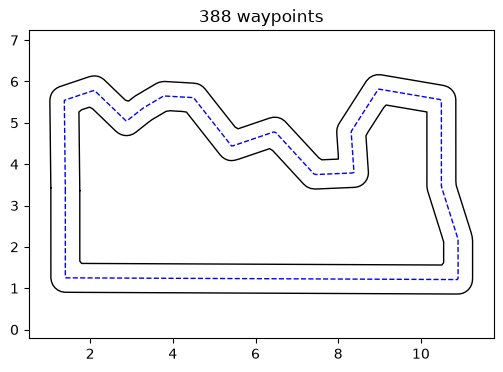

In [7]:
import matplotlib.pyplot as plt

route = requests.get(f"{BASE_URL}/route").json()

plt.figure(figsize=(6, 4))
for key, style in (("inner", "k-"), ("outer", "k-"), ("waypoints", "b--")):
    line = route.get(key)
    if line:
        xs, ys = zip(*line)
        plt.plot(xs, ys, style, linewidth=1)
plt.axis("equal")
plt.title(f"{len(route['waypoints'])} waypoints")
plt.show()

### 3.3. Bounds

`GET /bounds` — track bounding box.

In [8]:
requests.get(f"{BASE_URL}/bounds").json()

{'minX': 0.0, 'maxX': 12.0, 'minY': 0.0, 'maxY': 7.0}

### 3.4. Objects

`GET /objects` — world models (name, `type`: object/wall/light, static, movable, origin/current pose, size).

In [9]:
objects = requests.get(f"{BASE_URL}/objects").json()["objects"]
objects

[{'name': 'cone2',
  'type': 'object',
  'static': False,
  'movable': True,
  'origin': {'x': 8.3253, 'y': 1.039, 'z': 0.19, 'yaw': 0.0},
  'current': {'x': 8.3253,
   'y': 1.039,
   'z': 0.19,
   'yaw': -0.0,
   'q': [-0.0, 0.0, -0.0, 1.0]},
  'size': {'x': 0.18, 'y': 0.18, 'z': 0.38}},
 {'name': 'light1',
  'type': 'light',
  'static': False,
  'movable': True,
  'origin': {'x': 1.007, 'y': 2.8238, 'z': 0.0, 'yaw': 1.3788},
  'current': {'x': 1.007,
   'y': 2.8238,
   'z': 4.9e-05,
   'yaw': 1.3788,
   'q': [-0.0, -0.0, 0.636074, 0.771628]},
  'size': {'x': 0.0326, 'y': 0.08, 'z': 0.1415}},
 {'name': 'cone4',
  'type': 'object',
  'static': False,
  'movable': True,
  'origin': {'x': 9.7342, 'y': 1.3917, 'z': 0.19, 'yaw': 0.0},
  'current': {'x': 9.7342,
   'y': 1.3917,
   'z': 0.19,
   'yaw': 0.0,
   'q': [-1e-06, 1e-06, 0.0, 1.0]},
  'size': {'x': 0.18, 'y': 0.18, 'z': 0.38}},
 {'name': 'cone1',
  'type': 'object',
  'static': False,
  'movable': True,
  'origin': {'x': 10.3125, '

### 3.5. Move an object

`POST /models/<name>/pose` — `{"x", "y", "z", "yaw"}`; omitted fields keep their value, rotation is yaw-only. Works for World Builder objects and traffic lights; walls and the track itself are rejected. The response returns after the pose is confirmed applied.

In [10]:
objects = requests.get(f"{BASE_URL}/objects").json()["objects"]
target = next(o for o in objects if o["movable"])
print("moving", target["name"])
requests.post(f"{BASE_URL}/models/{target['name']}/pose",
              json={"x": target["current"]["x"] + 0.2}).json()

moving cone2


{'ok': True,
 'applied': True,
 'model': {'name': 'cone2',
  'x': 8.5253,
  'y': 1.039,
  'z': 0.191,
  'yaw': -0.0,
  'type': 'object'}}

## [4] Traffic Lights

### 4.1. List

`GET /traffic_lights` — the world's traffic lights and their states. Default state is `green`; states survive a respawn of the same world.

In [11]:
lights = requests.get(f"{BASE_URL}/traffic_lights").json()["lights"]
lights

[{'name': 'light1',
  'x': 1.007,
  'y': 2.8238,
  'yaw': 1.3788,
  'state': 'green',
  'builtin': True,
  'panel': {'px': 0.00751,
   'pz': 0.07206,
   'pitch': -0.1745,
   'lamp_r': 0.02784}}]

### 4.2. Change state

`POST /traffic_lights/<name>` — `{"state": "red"}` or `{"state": "green"}`. green→red passes through 3 s of yellow, during which commands are rejected with 409.

In [12]:
import time

lights = requests.get(f"{BASE_URL}/traffic_lights").json()["lights"]
if lights:
    name = lights[0]["name"]
    print(requests.post(f"{BASE_URL}/traffic_lights/{name}", json={"state": "red"}).json())
    time.sleep(3.5)  # let the yellow transit finish
    print(requests.post(f"{BASE_URL}/traffic_lights/{name}", json={"state": "green"}).json())

{'ok': True, 'light': {'name': 'light1', 'x': 1.007, 'y': 2.8238, 'yaw': 1.3788, 'state': 'yellow', 'builtin': True, 'panel': {'px': 0.00751, 'pz': 0.07206, 'pitch': -0.1745, 'lamp_r': 0.02784}, 'yellow_until': 1787053056.474}}
{'ok': True, 'light': {'name': 'light1', 'x': 1.007, 'y': 2.8238, 'yaw': 1.3788, 'state': 'green', 'builtin': True, 'panel': {'px': 0.00751, 'pz': 0.07206, 'pitch': -0.1745, 'lamp_r': 0.02784}}}


## [5] Reset

### 5.1. Reset

`POST /reset` — every movable object, traffic light and the vehicle back at its start pose. Instant, pose-only, no world reload — the go-to reset between training episodes (this also undoes the teleport and object move above).

In [13]:
requests.post(f"{BASE_URL}/reset").json()

{'ok': True,
 'reset': ['cone2',
  'light1',
  'cone4',
  'cone1',
  'cone3',
  'cone5',
  'cone6',
  'physicar']}

### 5.2. Respawn

`POST /respawn` — reload the whole world (~6 s), the heavyweight reset for when the world misbehaves. Not executed here:

```python
requests.post(f"{BASE_URL}/respawn")
```

## [6] Display

### 6.1. Brightness

`GET /brightness`, `POST /brightness` — `{"value": 0.2..2.0}`, 1.0 = default. Applied instantly at the display layer (3D viewer + robot camera frames together); one shared server-side value, persists across world switches and restarts.

In [14]:
print(requests.get(f"{BASE_URL}/brightness").json())
requests.post(f"{BASE_URL}/brightness", json={"value": 1.0}).json()

{'value': 1.0}


{'ok': True, 'value': 1.0}

### 6.2. Overlay

`POST /overlay` — show status text on the `/sim` screen (`{"text": "...", "ttl": 10}` — text ≤300 chars, ttl 1–3600 s; expires by itself, e.g. training progress). `GET /overlay` reads the current text.

In [15]:
requests.post(f"{BASE_URL}/overlay", json={"text": "Hello from the API", "ttl": 5}).json()

{'ok': True}

## [7] Monitoring

### 7.1. State

`GET /state` — one-call snapshot of everything that changes in real time: world/running/switching, sim `time`/`paused`/`rtf`, vehicle pose, object poses, traffic lights, overlay, brightness, and the evaluation run state.

In [16]:
requests.get(f"{BASE_URL}/state").json()

{'world': 'custom_71e69ee938032295503bfed557fde18c',
 'running': True,
 'switching': False,
 'time': 321.145,
 'paused': False,
 'rtf': 0.9997950420163867,
 'vehicle': {'x': 1.400002,
  'y': 3.386107,
  'z': -0.0,
  'yaw': -1.570679,
  'q': [0.0, 0.0, -0.707065, 0.707148]},
 'objects': {'cone2': {'x': 8.3253,
   'y': 1.039,
   'z': 0.19,
   'yaw': -0.0,
   'q': [0.0, 0.0, -0.0, 1.0]},
  'cone4': {'x': 9.7342,
   'y': 1.3917,
   'z': 0.19,
   'yaw': -0.0,
   'q': [0.0, -0.0, -0.0, 1.0]},
  'cone1': {'x': 10.3125,
   'y': 3.8411,
   'z': 0.19,
   'yaw': -0.0,
   'q': [0.0, 0.0, -0.0, 1.0]},
  'cone3': {'x': 8.1614,
   'y': 4.4346,
   'z': 0.19,
   'yaw': 0.0593,
   'q': [-0.0, 0.0, 0.029646, 0.99956]},
  'cone5': {'x': 4.1759,
   'y': 5.8084,
   'z': 0.189999,
   'yaw': -0.0663,
   'q': [-0.0, 0.0, -0.033144, 0.999451]},
  'cone6': {'x': 1.202,
   'y': 4.7708,
   'z': 0.19,
   'yaw': -0.0,
   'q': [0.0, 0.0, -0.0, 1.0]},
  'light1': {'x': 1.007,
   'y': 2.8238,
   'z': 4.9e-05,
   'yaw':

### 7.2. Events (SSE)

`GET /events` — SSE stream of **named events**. `event: state` — full status snapshot pushed on change; `event: run` — student-process events during an evaluation. Consumers MUST ignore unknown event names.

In [17]:
# Read the first pushed state event, then close the stream
with requests.get(f"{BASE_URL}/events", stream=True, timeout=10) as r:
    for line in r.iter_lines():
        print(line.decode()[:120])
        if line.startswith(b"data:"):
            break

event: state
data: {"running": true, "websocket": true, "current": "custom_71e69ee938032295503bfed557fde18c", "switching": false, "ov


## [8] Evaluation

`POST /evaluation/run` launches the student's code (`{"command"?, "time_limit_s"?}` — output streams to `event: run` on `/events`); `POST /evaluation/stop` stops it (idempotent). Normally driven by the ▶ button on the `/sim` page — not executed here.

### 8.1. Evaluation document

`GET /evaluation` — the current world's evaluation document (`{version, config, script}`), 404 when the world has none.

In [18]:
r = requests.get(f"{BASE_URL}/evaluation")
print(r.status_code)
if r.ok:
    print(r.json()["config"])

200
{'description': '미션: 한바퀴를 빠르게 완주 (제한시간 3분)\n패널티 5초: 충돌, 4바퀴 이탈\n패널티 10초: 빨간불 출발', 'better': 'lower', 'time_limit_s': 180, 'robot': 'physicar', 'run_command': 'source /home/physicar/physicar_ws/run.sh'}


## [9] Worlds

### 9.1. Worlds

`GET /worlds` — world list (includes the current one): `name`, `file`, `display`, `world_id`, `official`, `evaluation`, `deletable`.

In [19]:
requests.get(f"{BASE_URL}/worlds").json()

{'worlds': [{'name': 'physicar_base',
   'file': 'physicar_base.world',
   'display': 'PhysiCar Base',
   'world_id': None,
   'size': [5, 5],
   'official': True,
   'evaluation': False,
   'deletable': False},
  {'name': 'custom_71e69ee938032295503bfed557fde18c',
   'file': 'custom_71e69ee938032295503bfed557fde18c.world',
   'display': 'AMET 2026',
   'world_id': '71e69ee938032295503bfed557fde18c',
   'size': [12, 7],
   'official': False,
   'evaluation': True,
   'deletable': True},
  {'name': 'custom_e09090b056ef1f90f845419690065271',
   'file': 'custom_e09090b056ef1f90f845419690065271.world',
   'display': '대회연습',
   'world_id': 'e09090b056ef1f90f845419690065271',
   'size': [12, 7],
   'official': False,
   'evaluation': True,
   'deletable': True}],
 'current': 'custom_71e69ee938032295503bfed557fde18c'}

### 9.2. Switch

`POST /switch` — switch world by file name or publish id; the id form resolves an installed published world and returns 404 when it is not installed. Takes several seconds (full world load) — not executed here:

```python
requests.post(f"{BASE_URL}/switch", json={"world": "physicar_base.world"})
# or by publish id:
requests.post(f"{BASE_URL}/switch", json={"world_id": "<32-hex id>"})
```

### 9.3. World publishing

`GET /worldpub` — current world's publish coordinates and the assets CDN revision. `POST /worlds/install` installs a published world from the CDN (`{"world_id": "<32-hex id>"}`, skipped with `"cached": true` when the same `rev` is already installed).

In [20]:
requests.get(f"{BASE_URL}/worldpub").json()

{'world': 'custom_71e69ee938032295503bfed557fde18c',
 'world_id': '71e69ee938032295503bfed557fde18c',
 'rev': 'msxw4l0xae4bc354',
 'assets_rev': 'v1.1.12',
 'static_rev': 'v1.1.12',
 'cdn': 'https://worlds.physicar.ai'}